In [1]:
import torch
import torch.nn as nn

import torch_geometric as tg
import torch_geometric.utils as tgu
import torch_geometric.nn as tgnn
import matplotlib.pyplot as plt

import numpy as np

## Notes from graphcast
 - there are multiple layers of nodes -> some nodes propagate information to more distant nodes
 - loss function takes into account multiple factors - e.g. sample density
 - autoregressive training 
   - model is trained using fix interval
   - to predict more distant (in time) points then previous prediction of a model is used
   - predicting 10 day ahead tends to have large overfitting
 - gnn was selected because weather function is the same in every place of the globe

In [2]:
omega = 1.8

feature_vec_len = 8
x = np.arange(0,6.4,0.1).reshape((-1,1))
t = np.arange(0,6,0.1).reshape([-1,1])

values = np.sin(omega*t+x.T)

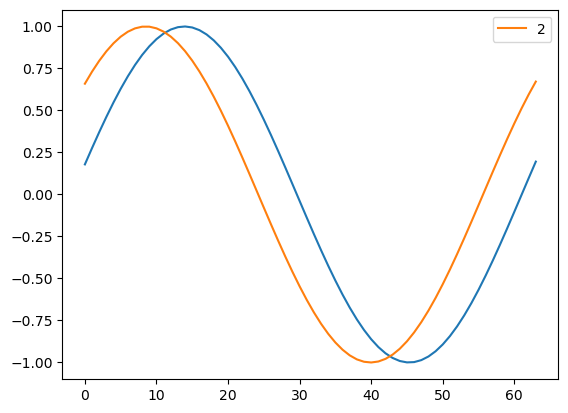

In [3]:
plt.plot(values[1,:])
plt.plot(values[4,:], label='2')
plt.legend()

In [52]:
def get_sample(values, dt=4, inclusion_prob=0.5):
    time_horizon, positions = values.shape

    fully_connected_adj = torch.ones(positions, positions)
    fully_connected = tgu.dense_to_sparse(fully_connected_adj)[0]

    sample = []
    sample_dt = []

    time_stamp = np.random.randint(dt, time_horizon - 2*dt)
    time_to_predict = time_stamp + np.random.randint(1, 2*dt)

    is_included = np.random.random(positions) > inclusion_prob
    for idx, included in zip(range(positions), is_included):
        _time = time_stamp + np.random.randint(-dt, dt)
        sample.append((
            idx/positions,
            included*1.0,
            values[_time, idx] * included,
            _time/64,
            time_to_predict/64,
        ))
        sample_dt.append((
            idx/positions,
            1.0,
            values[time_to_predict, idx],
            time_to_predict/64,
            time_to_predict/64,
        ))

    return (
        torch.tensor(sample, dtype=torch.float32, requires_grad=False),
        torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),
        torch.tensor(sample_dt, dtype=torch.float32, requires_grad=False)
    )

In [53]:
class feature_encoder(nn.Module):
    def __init__(self, dims=None, output_feature_num=feature_vec_len):
        nn.Module.__init__(self)

        if dims is None:
            self.dims = {
                "time": 1,
                "x_pos": 1,
                "value": 1,
            } 
        else:
            self.dims = dims

        self.input_dimensionality = sum(self.dims.values())

        self.seq = nn.Sequential(
            nn.Linear(self.input_dimensionality, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU(),
            nn.Linear(32, output_feature_num),
            nn.Tanh()
        )

    def forward(self, x):
        return self.seq(x)

In [54]:
fe_model = feature_encoder(dims = {
                "x_pos": 1,
                "value": 1,
                "certaininty": 1,
                "time": 1,
                "prediction_time":1,
            } )
te = feature_encoder({'time': 1}, output_feature_num=16)
sample = get_sample(values)
fe_model(sample[0])

/tmp/ipykernel_62006/1968012416.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


tensor([[-1.9069e-02, -3.5169e-02,  6.6140e-02,  7.9509e-02, -1.3462e-02,
          9.1519e-02, -1.5319e-01,  6.9789e-02],
        [-1.8307e-02, -3.6336e-02,  6.5914e-02,  7.9767e-02, -1.3692e-02,
          9.1289e-02, -1.5326e-01,  7.0043e-02],
        [-9.4896e-02, -5.9845e-02, -1.3500e-02,  6.0176e-02,  2.0507e-02,
          6.7433e-02, -1.6871e-01,  7.7712e-02],
        [-1.7523e-02, -3.6453e-02,  6.5947e-02,  8.0636e-02, -1.4368e-02,
          9.0398e-02, -1.5384e-01,  7.0242e-02],
        [-1.6509e-02, -3.8329e-02,  6.5586e-02,  8.0791e-02, -1.4538e-02,
          9.0328e-02, -1.5375e-01,  7.0587e-02],
        [-1.6980e-02, -3.5825e-02,  6.6139e-02,  8.1623e-02, -1.5131e-02,
          8.9354e-02, -1.5455e-01,  7.0339e-02],
        [-1.5715e-02, -3.8423e-02,  6.5642e-02,  8.1673e-02, -1.5230e-02,
          8.9448e-02, -1.5430e-01,  7.0778e-02],
        [-9.0230e-02, -5.9421e-02, -1.3135e-02,  6.3350e-02,  1.8908e-02,
          6.5673e-02, -1.7072e-01,  7.8213e-02],
        [-9.1016

In [55]:
# x_cord, y_cord, time
# time_embed 


class gnn_model(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.gnn_out_ch = 32
        self.edge_vector_len = 16
        edge_params_shape = values.shape[1]**2
        #self.fe = feature_encoder()
        self.edge_params = nn.Parameter(torch.randn([edge_params_shape, self.edge_vector_len])/20)

        self.l1 = tgnn.GAT(
            in_channels=5,#feature_vec_len,
            hidden_channels=4*feature_vec_len,
            num_layers=3,
            out_channels=self.gnn_out_ch,
            dropout=0.1,
            act='gelu',
            edge_dim=self.edge_vector_len,
            v2=True,
        )
        self.l2 = nn.Linear(self.gnn_out_ch, 2)

    def forward(self, nodes, edges):
        encoded_features = nodes#self.fe(nodes)

        g_output = self.l1(encoded_features, edges, edge_attr=self.edge_params)
        dense_output = self.l2(g_output)

        return dense_output



In [63]:
model = gnn_model()

In [64]:
model(
    sample[0],
    sample[1],
).shape

torch.Size([64, 2])

In [65]:
sample[2][:,-3]

tensor([-0.4425, -0.5298, -0.6119, -0.6878, -0.7568, -0.8183, -0.8716, -0.9162,
        -0.9516, -0.9775, -0.9937, -0.9999, -0.9962, -0.9825, -0.9589, -0.9258,
        -0.8835, -0.8323, -0.7728, -0.7055, -0.6313, -0.5507, -0.4646, -0.3739,
        -0.2794, -0.1822, -0.0831,  0.0168,  0.1165,  0.2151,  0.3115,  0.4048,
         0.4941,  0.5784,  0.6570,  0.7290,  0.7937,  0.8504,  0.8987,  0.9380,
         0.9679,  0.9882,  0.9985,  0.9989,  0.9894,  0.9699,  0.9407,  0.9022,
         0.8546,  0.7985,  0.7344,  0.6630,  0.5849,  0.5010,  0.4121,  0.3191,
         0.2229,  0.1245,  0.0248, -0.0752, -0.1743, -0.2718, -0.3665, -0.4575])

In [66]:
NUM_TR_STEPS = 1024*32
loss_t_0 = []
loss_t_dt = []
optimizer = torch.optim.AdamW(model.parameters(),lr=1e-2,)
loss_fn = nn.MSELoss()

for i in range(NUM_TR_STEPS):
    sample = get_sample(values)

    y_hat = model(
        sample[0],
        sample[1],
    )

    loss = loss_fn(sample[2][:,-3], y_hat[:,-1])
    
    # check if this is correct place for zero grad
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i%10 == 0:
        l_dt = ((sample[2][:,-3] - y_hat[:,-1])**2).T
        loss_t_dt.append(l_dt.detach())
        print(f"l_dt:{torch.mean(l_dt)}")



/tmp/ipykernel_62006/1968012416.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


l_dt:0.4987378418445587
l_dt:0.4956930875778198
l_dt:0.49246370792388916
l_dt:0.4967464208602905
l_dt:0.49284228682518005
l_dt:0.49338191747665405
l_dt:0.4916881024837494
l_dt:0.508154571056366
l_dt:0.49625685811042786
l_dt:0.49910205602645874
l_dt:0.5039656758308411
l_dt:0.49356335401535034
l_dt:0.4952539801597595
l_dt:0.4938535690307617
l_dt:0.5059004426002502
l_dt:0.4917686879634857
l_dt:0.49544745683670044
l_dt:0.4909052848815918
l_dt:0.5088217258453369
l_dt:0.5022181272506714
l_dt:0.4930250346660614
l_dt:0.5039893388748169
l_dt:0.5076336860656738
l_dt:0.5085547566413879
l_dt:0.49235445261001587
l_dt:0.5088061094284058
l_dt:0.4919642210006714
l_dt:0.4910111129283905
l_dt:0.5077206492424011
l_dt:0.5029422044754028
l_dt:0.5091818571090698
l_dt:0.49679526686668396
l_dt:0.5081912875175476
l_dt:0.5015673637390137
l_dt:0.5053621530532837
l_dt:0.5089305639266968
l_dt:0.49979689717292786
l_dt:0.49683794379234314
l_dt:0.5091112852096558
l_dt:0.4909215569496155
l_dt:0.5056540369987488
l_dt:0

KeyboardInterrupt: 

In [49]:
torch.mean((
    #y_hat[:,-1:] - sample[2][:,-1:])**2)
    sample[0][:,-1:] - sample[2][:,-1:])**2)

tensor(0.)

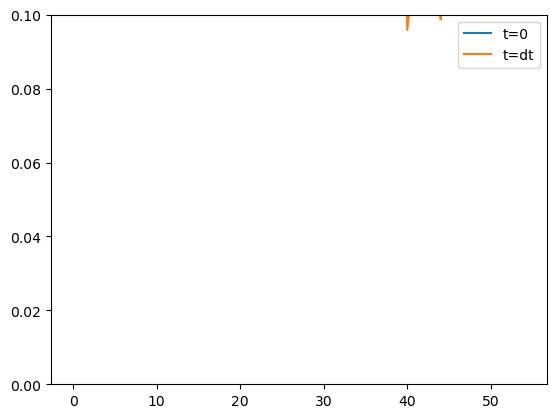

In [67]:
mean_over = 20
t0 = np.array([torch.mean(x).item() for x in loss_t_0])
t0_mean = t0[t0.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

t_dt = np.array([torch.mean(x).item() for x in loss_t_dt])
t_dt_mean = t_dt[t_dt.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

plt.plot(t0_mean, label='t=0')
plt.plot(t_dt_mean, label='t=dt')
plt.legend()
plt.ylim(0.0,.1)
plt.show()

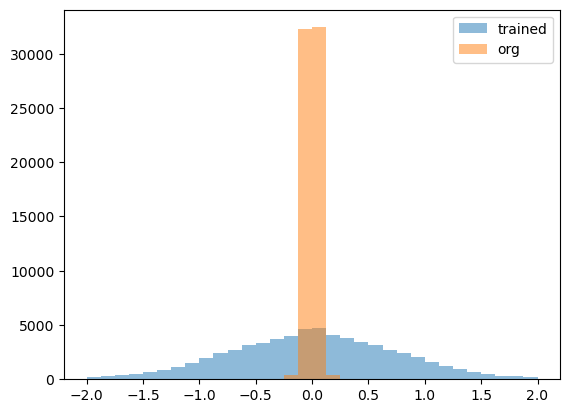

In [68]:
plt.hist(model.edge_params.detach().flatten(), bins=32, label='trained', alpha=0.5,range=(-2,2))
plt.hist((torch.randn(model.edge_params.shape)/20).flatten(), bins=32, label='org', alpha=0.5,range=(-2,2))
plt.legend()
plt.show()

/tmp/ipykernel_62006/1968012416.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


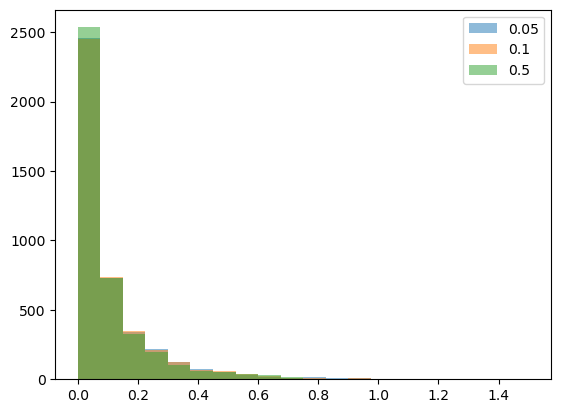

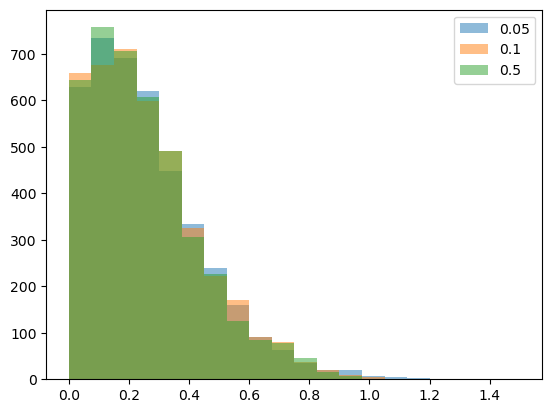

In [83]:
NUM_TEST_STEPS = 64
res_dict = {}

with torch.no_grad():
    for inc_prob in [.05,.1,.5]:
        loss_te_dt = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(values,inclusion_prob=0.2)

            y_hat = model(
                sample[0],
                sample[1],
            )

            l_dt = ((sample[2][:,-3] - y_hat[:,-1])**2).T
            loss_te_dt.append(l_dt.detach())
        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()

for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
plt.legend()
plt.show()

for label, part_res in res_dict.items():
    plt.hist(part_res**0.5,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
plt.legend()
plt.show()

/tmp/ipykernel_62006/1968012416.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


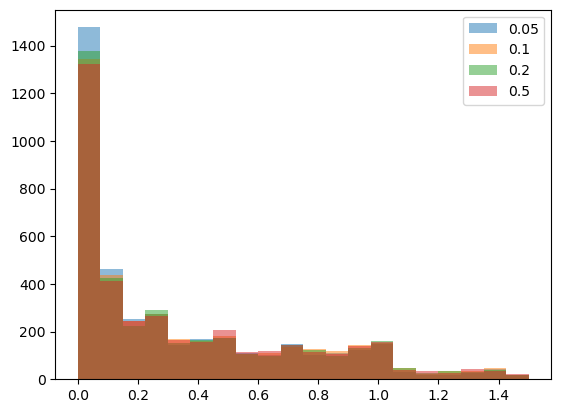

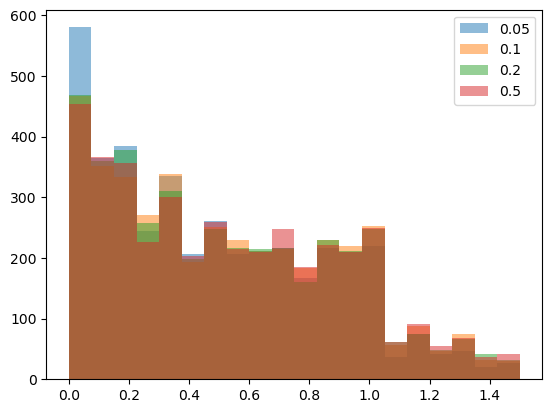

In [84]:
NUM_TEST_STEPS = 64
res_dict = {}

with torch.no_grad():
    for inc_prob in [.05,.1,.2,.5]:
        loss_te_dt = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(values,inclusion_prob=0.2)

            l_dt = ((sample[2][:,-3] - sample[0][:,-3])**2).T
            loss_te_dt.append(l_dt.detach())
        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()

for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
plt.legend()
plt.show()

for label, part_res in res_dict.items():
    plt.hist(part_res**0.5,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
plt.legend()
plt.show()